<a href="https://colab.research.google.com/github/Taliferreira01/MountairShooter/blob/master/trabalho_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comandos para realização do trabalho da matéria de NLP com uso da biblioteca SKlearn e NLTK.

## <font color=red>Observação importante:</font>

<font color=yellow>Trabalho realizado com uso de corpus diferente do Fake.br não será aceito!</font>

## Carregando arquivos `pre-processed.csv`, de imagem e de funções auxiliares para dentro do Google Colab

In [25]:
!wget https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/master/preprocessed/pre-processed.csv -O pre-processed.csv
!git clone https://github.com/N-CPUninter/NLP.git
!rm ./NLP/*.ipynb
!mv ./NLP/* .
!rm -r NLP

--2025-12-04 00:52:04--  https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/master/preprocessed/pre-processed.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20434897 (19M) [text/plain]
Saving to: ‘pre-processed.csv’

pre-processed.csv   100%[===================>]  19.49M  --.-KB/s    in 0.06s   

2025-12-04 00:52:04 (305 MB/s) - ‘pre-processed.csv’ saved [20434897/20434897]

Cloning into 'NLP'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 34 (delta 9), reused 25 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 1.27 MiB | 24.15 MiB/s, done.
Resolving deltas: 100% (9/9), done.
mv: cannot move './NLP/data' to './data': Directory

## Instalação manual das dependências para uso do SKlearn e do NLTK no Google Colab

In [26]:
import pandas as pd
import nltk
from nltk import ngrams
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from funcoes_auxiliares import gerar_nuvem_palavras

nltk.download("all")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

## Criar dataframe do CSV utilizando o método read_csv do pandas

In [27]:
df = pd.read_csv('pre-processed.csv')

In [28]:
df.head()

,index,label,preprocessed_news
0,0,fake,katia abreu diz vai colocar expulsao moldura n...
1,1,fake,ray peita bolsonaro conservador fake entrevist...
2,2,fake,reinaldo azevedo desmascarado policia federal ...
3,3,fake,relatorio assustador bndes mostra dinheiro pub...
4,4,fake,radialista americano fala sobre pt vendem ilus...


In [61]:
df['qt_palavras'] = df['preprocessed_news'].astype(str).map(lambda x: len(x.split()))
print(df.groupby('label')['qt_palavras'].sum())


label
fake     388587
true    2249768
Name: qt_palavras, dtype: int64


# PRÁTICA 1 - CRIAÇÃO DE MODELO DE CLASSIFICAÇÃO SUPERVISIONADO PARA ANÁLISE DE FAKE NEWS.

1. Realize os seguintes procedimentos de limpeza dos textos do dataframe criado:

  1.1. Tokenizar

  1.2. Retirar os acentos e números

  1.3. Deixar tudo em minúsculas

  1.4. Retirar as stopwords e pontuações

  1.5. Deixar palavras apenas com radical (STEM)

  1.6. Realizar truncamento dos pares de notícias verdadeiras com falsas para normalizar quantidade de palavras

  1.7. Remontar as notícias em string e criar coluna no dataframe para o resultado deste pré-processamento.

2. Criar matriz de frequências TF-IDF com ngramas de 1 a 3 palavras.

3. Usar a função train_test_split do Scikit Learn para dividir o corpus pré-tratado em 75% dos textos para treinamento e 25% para testes de precisão (usar random_state = 42 ou outro número de sua escolha).

4. Fazer regressão logística com solver = 'lbfgs'.

5. Realizar predição dos textos de teste com o método predict_proba, que retornará a porcentagem predita para fake e para real em um array.

6. Por fim, com as porcentagens calculadas para cada texto de teste, usar a função accuracy_score da biblioteca Scikit Learn para calcular a acurácia geral do algoritmo.

In [29]:
# Coloque seu código aqui
import re
import unicodedata
import string
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('rslp')  # stemmer resources

from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# -- Pré-checagens rápidas --
print("Shape:", df.shape)
print("Colunas:", df.columns.tolist())
print(df.label.value_counts())

# Cell: Funções de pré-processamento
pt_stopwords = set(stopwords.words('portuguese'))
stemmer = RSLPStemmer()
punct_table = str.maketrans('', '', string.punctuation)  # remove pontuação ASCII básica

def remove_acentos(text):
    # Normaliza para remover acentos
    nfkd = unicodedata.normalize('NFKD', text)
    return ''.join([c for c in nfkd if not unicodedata.combining(c)])

def apenas_letras_espaco(text):
    # Remove números e preserva letras e espaços
    # também remove underscore e outros símbolos não-alfabéticos
    return re.sub(r'[^A-Za-zÀ-ÖØ-öø-ÿçÇ\s]', ' ', text)

def preprocess_tokens(text):
    # 1) remover acentos
    text = remove_acentos(text)
    # 2) retirar números e caracteres indesejados (ficam só letras e espaços)
    text = apenas_letras_espaco(text)
    # 3) minúsculas
    text = text.lower()
    # 4) tokenizar
    tokens = word_tokenize(text, language='portuguese')
    # 5) remover stopwords e pontuação (já filtrada, mas checagem)
    tokens = [t for t in tokens if t not in pt_stopwords and t.strip() != '']
    # 6) stem (radical)
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens

# Cell: aplicar preprocess para obter tokens e calcular mediana de tamanho
# Note: pode ser lento dependendo do tamanho do dataset — ajustável.
df['tokens_preproc'] = df['preprocessed_news'].astype(str).map(preprocess_tokens)

# calcular mediana do comprimento em tokens
comprimentos = df['tokens_preproc'].map(len)
mediana_len = int(np.median(comprimentos))
print("Comprimentos (min, mediana, max):", comprimentos.min(), mediana_len, comprimentos.max())

# Cell: truncamento para normalizar (1.6)
# Aqui truncamos cada token list para mediana_len tokens (se menor, mantemos como está)
def truncar_tokens(tokens, max_len):
    if len(tokens) > max_len:
        return tokens[:max_len]
    else:
        return tokens

df['tokens_trunc'] = df['tokens_preproc'].map(lambda x: truncar_tokens(x, mediana_len))

# Cell: remontar em string (1.7)
df['text_final'] = df['tokens_trunc'].map(lambda tokens: ' '.join(tokens))

# Verificar
print(df[['label','preprocessed_news','text_final']].head(5))

# Cell: criação da matriz TF-IDF com n-gramas de 1 a 3
vectorizer = TfidfVectorizer(ngram_range=(1,3), min_df=2)  # min_df=2 evita termos muito raros; ajustar se quiser
X = vectorizer.fit_transform(df['text_final'])
print("TF-IDF shape:", X.shape)

# Preparar y (encode dos labels)
le = LabelEncoder()
y = le.fit_transform(df['label'])  # por exemplo: 'fake'->0, 'true'->1 (verifique ordem com le.classes_)

print("Classes (LabelEncoder):", le.classes_)

# Cell: dividir treino/teste (75% treino, 25% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Tamanhos: X_train, X_test =", X_train.shape, X_test.shape)

# Cell: treinar Regressão Logística solver='lbfgs'
clf = LogisticRegression(solver='lbfgs', max_iter=1000)
clf.fit(X_train, y_train)

# Cell: predicao com predict_proba e avaliação
probs = clf.predict_proba(X_test)  # shape (n_samples, n_classes)
# Exemplo de visualização das primeiras linhas
print("Exemplo predict_proba (5 primeiros):\n", probs[:5])

# converter probs para classes previstas (argmax)
y_pred = np.argmax(probs, axis=1)

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia geral: {acc:.2f}")

# Opcional: show classification distribution
from sklearn.metrics import classification_report, confusion_matrix
print("Relatório:\n", classification_report(y_test, y_pred, target_names=le.classes_))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


Shape: (7200, 3)
Colunas: ['index', 'label', 'preprocessed_news']
label
fake    3600
true    3600
Name: count, dtype: int64
Comprimentos (min, mediana, max): 5 209 4214
  label                                  preprocessed_news  \
0  fake  katia abreu diz vai colocar expulsao moldura n...   
1  fake  ray peita bolsonaro conservador fake entrevist...   
2  fake  reinaldo azevedo desmascarado policia federal ...   
3  fake  relatorio assustador bndes mostra dinheiro pub...   
4  fake  radialista americano fala sobre pt vendem ilus...   

                                          text_final  
0  kat abr diz vai coloc expulsa mold nao reclam ...  
1  ray peit bolsonar conserv fak entrev danil gen...  
2  reinald azeved desmascar polic feder ferrenh c...  
3  relatori assust bnd mostr dinh publ brasil jor...  
4  radial americ fal sobr pt vend ilusa pov brasi...  
TF-IDF shape: (7200, 205610)
Classes (LabelEncoder): ['fake' 'true']
Tamanhos: X_train, X_test = (5400, 205610) (1800, 205610)
E

## QUESTÃO 01: Apresente aqui o código referente ao modelo gerado e a nuvem de palavras que foram usadas para identificar textos VERDADEIROS.

1. Formate seus dados usados para o treinamento do seu modelo em um dicionário de tokens e suas frequências.
2. Separe os dados em um grupo com textos marcados como verdadeiros e outro com os falsos.
3. Use a função gerar_nuvem_palavras(dic_de_frequências_textos_verdadeiras, imagem de sua escolha) para gerar a nuvem de palavras


In [37]:
import re
import string
import unicodedata
import nltk
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("rslp")

stopwords_pt = set(stopwords.words("portuguese"))
stemmer = RSLPStemmer()

def remove_acentos(texto):
    nfkd = unicodedata.normalize('NFKD', texto)
    return "".join([c for c in nfkd if not unicodedata.combining(c)])

def limpar_texto(texto):
    texto = remove_acentos(texto.lower())
    texto = re.sub(r"[^a-zA-Z\s]", " ", texto)
    tokens = word_tokenize(texto, language="portuguese")
    tokens = [t for t in tokens if t not in stopwords_pt and len(t) > 2]
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


In [45]:
# Separando textos verdadeiros e falsos
df_verdadeiro = df[df['label'] == 'true']
df_falso = df[df['label'] == 'fake']

print("Qtd verdadeiras:", len(df_true))
print("Qtd falsas:", len(df_fake))


Qtd verdadeiras: 3600
Qtd falsas: 3600


Top 20 tokens de notícias VERDADEIRAS:
[('nao', 35892), ('sao', 9608), ('ser', 9608), ('tambem', 9531), ('lula', 8748), ('presidente', 8730), ('sobre', 8302), ('disse', 8183), ('anos', 8173), ('federal', 7648), ('ja', 7603), ('ainda', 7025), ('governo', 6812), ('segundo', 6782), ('r', 6248), ('ate', 5826), ('brasil', 5712), ('ha', 5688), ('temer', 5685), ('ter', 5634)]
   * Um total de 74445 tokens foram computadas a partir do conjunto de dados.



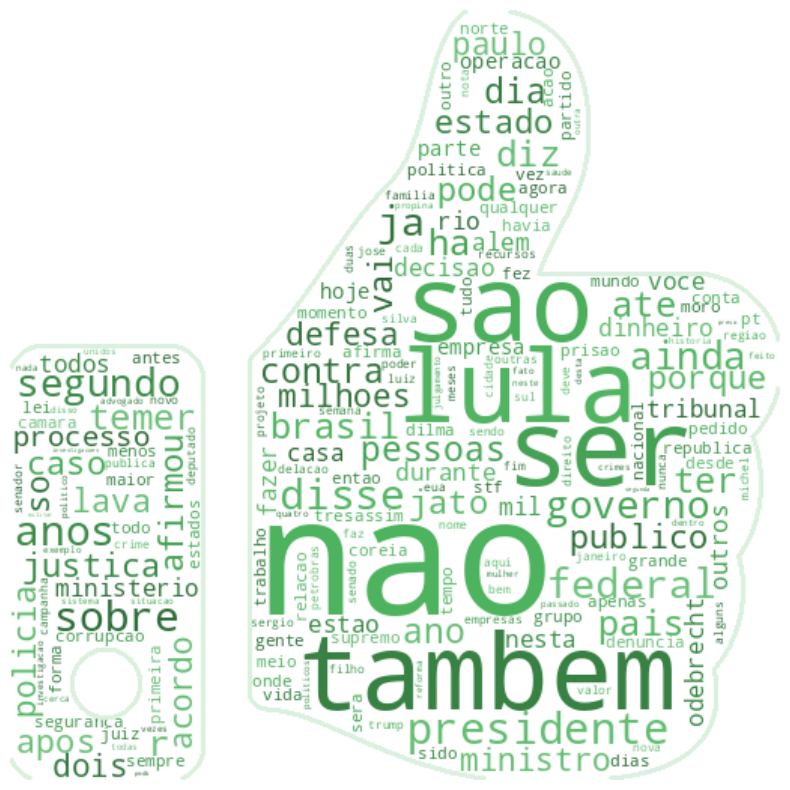

(<wordcloud.wordcloud.WordCloud at 0x78623ed05be0>, 74445)

In [80]:
# ============================================
# QUESTÃO 01 – Nuvem de Palavras (Textos VERDADEIROS)
# ============================================

import pandas as pd
from nltk.tokenize import word_tokenize
from collections import Counter
from funcoes_auxiliares import gerar_nuvem_palavras

# --------------------------------------------
# 1. Filtrar apenas textos marcados como VERDADEIROS
# --------------------------------------------
df_true = df[df["label"] == "true"]

# --------------------------------------------
# 2. Juntar todos os textos verdadeiros
# --------------------------------------------
texto_true = " ".join(df_true["preprocessed_news"].astype(str))

# --------------------------------------------
# 3. Tokenizar e gerar dicionário de frequências
# --------------------------------------------
tokens_true = word_tokenize(texto_true)
freq_true = dict(Counter(tokens_true))

# Exibir as 20 palavras mais frequentes (opcional)
print("Top 20 tokens de notícias VERDADEIRAS:")
print(Counter(tokens_true).most_common(20))

# ----------------------------------------------------
# 4. Gerar nuvem de palavras usando a função auxiliar
# ----------------------------------------------------

gerar_nuvem_palavras(
    dicionario_tokens_e_frequencia=freq_true,
    arquivo_mascara="thumbs_up_mask.png"
)


Top 20 tokens de notícias Verdadeiras:
[('nao', 35892), ('sao', 9608), ('ser', 9608), ('tambem', 9531), ('lula', 8748), ('presidente', 8730), ('sobre', 8302), ('disse', 8183), ('anos', 8173), ('federal', 7648), ('ja', 7603), ('ainda', 7025), ('governo', 6812), ('segundo', 6782), ('r', 6248), ('ate', 5826), ('brasil', 5712), ('ha', 5688), ('temer', 5685), ('ter', 5634)]
   * Um total de 74445 tokens foram computadas a partir do conjunto de dados.



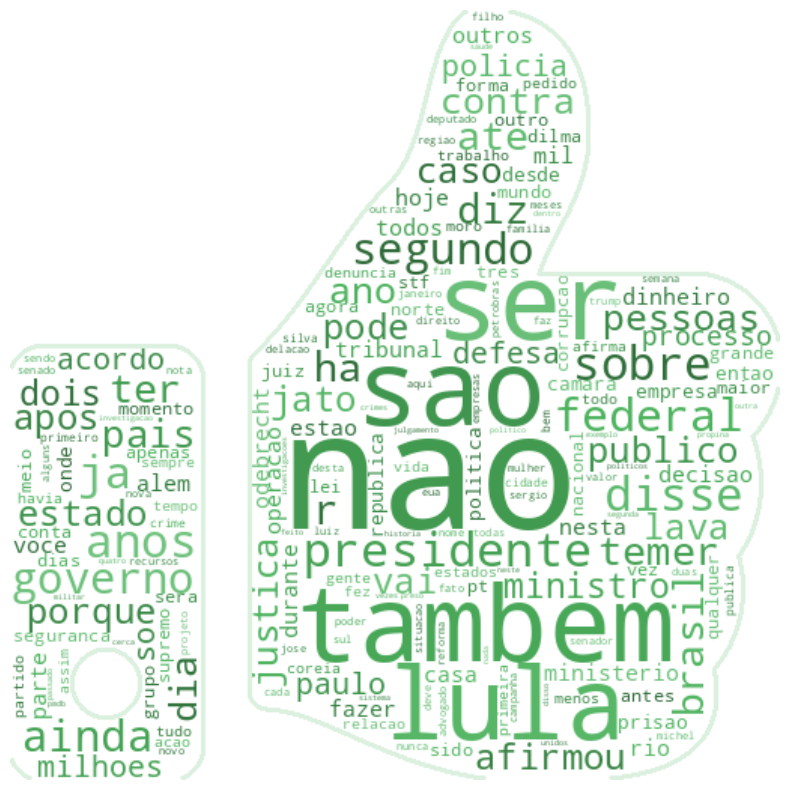

Número de unigramas: 14066
Número de bigramas: 131959
Número de trigramas: 59585
Acurácia do modelo: 0.9405555555555556


In [79]:
import pandas as pd
from nltk.tokenize import word_tokenize
from collections import Counter
from funcoes_auxiliares import gerar_nuvem_palavras


# 1. Filtrar apenas textos marcados como VERDADEIRO

df_verdadeiro = df[df["label"] == "true"]


# 2. Juntar todos os textos verdadeiro em uma única string

texto_verdadeiro = " ".join(df_verdadeiro["preprocessed_news"].astype(str))

# 3. Tokenizar e gerar dicionário de frequências

tokens_verdadeiro = word_tokenize(texto_verdadeiro)
freq_verdadeiro = dict(Counter(tokens_verdadeiro))

# 4. Gerar nuvem de palavras usando a função auxiliar

gerar_nuvem_palavras(
    dicionario_tokens_e_frequencia=freq_verdadeiro,
    arquivo_mascara="thumbs_up_mask.png"
)

num_unigramas = sum(1 for tok in vectorizer.vocabulary_ if len(tok.split()) == 1)
num_bigramas = sum(1 for tok in vectorizer.vocabulary_ if len(tok.split()) == 2)
num_trigramas = sum(1 for tok in vectorizer.vocabulary_ if len(tok.split()) == 3)
acuracia = accuracy_score(y_test, y_pred)

print('Número de unigramas:', num_unigramas)
print('Número de bigramas:', num_bigramas)
print('Número de trigramas:', num_trigramas)
print('Acurácia do modelo:', acuracia)



## QUESTÃO 02: Apresente aqui o código referente ao modelo gerado e a nuvem de palavras que foram usadas para identificar textos FALSOS.

1. Use a função gerar_nuvem_palavras(dic_de_frequências_textos_verdadeiras, imagem de sua escolha) para gerar a nuvem de palavras

In [39]:
df_fake = df[df["label"] == "fake"]
len(df_fake)


3600

   * Um total de 31771 tokens foram computadas a partir do conjunto de dados.



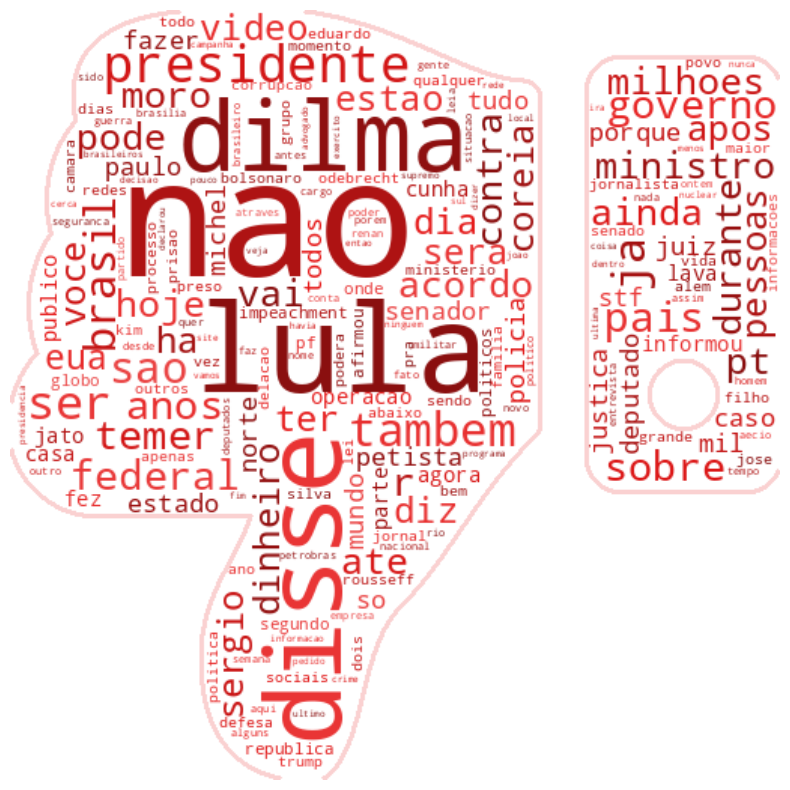

Número de unigramas: 14066
Número de bigramas: 131959
Número de trigramas: 59585
Acurácia do modelo: 0.9405555555555556


In [77]:
# QUESTÃO 02 – Nuvem de Palavras (Textos FALSOS)

import pandas as pd
from nltk.tokenize import word_tokenize
from collections import Counter
from funcoes_auxiliares import gerar_nuvem_palavras


# 1. Filtrar apenas textos marcados como FALSOS

df_falso = df[df["label"] == "fake"]


# 2. Juntar todos os textos falsos em uma única string

texto_falso = " ".join(df_falso["preprocessed_news"].astype(str))


# 3. Tokenizar e gerar dicionário de frequências
tokens_falsos = word_tokenize(texto_falso)
freq_falsas = dict(Counter(tokens_falsos))

# 4. Gerar nuvem de palavras usando a função auxiliar
gerar_nuvem_palavras(
    dicionario_tokens_e_frequencia=freq_falsas,
    arquivo_mascara="thumbs_down_mask.png",
)

num_unigramas = sum(1 for tok in vectorizer.vocabulary_ if len(tok.split()) == 1)
num_bigramas = sum(1 for tok in vectorizer.vocabulary_ if len(tok.split()) == 2)
num_trigramas = sum(1 for tok in vectorizer.vocabulary_ if len(tok.split()) == 3)
acuracia = accuracy_score(y_test, y_pred)

print('Número de unigramas:', num_unigramas)
print('Número de bigramas:', num_bigramas)
print('Número de trigramas:', num_trigramas)
print('Acurácia do modelo:', acuracia)




# Material Complementar

## Alguns exemplos de uso da função auxiliar
`gerar_nuvem_palavras(dicionario_tokens_e_frequencia, arquivo_mascara)`

Gera uma nuvem de palavras com base em seu dicionário de palavras ou ngramas
    como a chave e a frequência de aparição do token como valor (inteiro).

    Parâmetros:
        dicionario_tokens_e_frequencia (dict): O dicionário de tokens e suas
                                               respectivas frequências de
                                               aparição nos textos.
        arquivo_mascara (str): O nome do arquivo da imagem de máscara. Pde ser:
                                            cloud_mask.png
                                            mapa_brasil_mask.png
                                            thumbs_up_mask.png        
                                            thumbs_down_mask.png
                                            <Outro arquivo de sua escolha>

    Exemplos de Uso:
        1. Para gerar uma nuvem de palavras na máscara mapa do brasil:
            gerar_nuvem_palavras(dicionario_tokens_e_frequencia=word_dict,
                                 arquivo_mascara='mapa_brasil_mask.png')

   * Um total de 7 tokens foram computadas a partir do conjunto de dados.



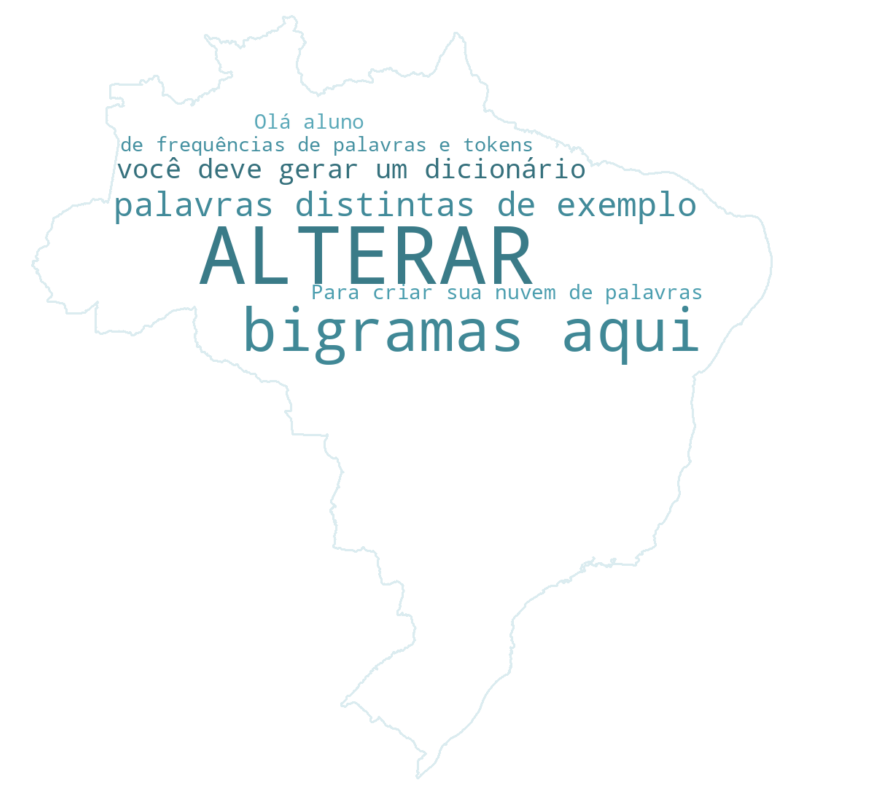

(<wordcloud.wordcloud.WordCloud at 0x784fdddbed40>, 7)

In [ ]:
# Exemplo com dicionário de tokens unigramas e multigramas com frequências
words_dict = {'Olá aluno':1,
              'ALTERAR':4,
              'bigramas aqui':2,
              'palavras distintas de exemplo':2,
              'Para criar sua nuvem de palavras':1,
              'você deve gerar um dicionário':2,
              'de frequências de palavras e tokens':1}
gerar_nuvem_palavras(dicionario_tokens_e_frequencia=words_dict,
                     arquivo_mascara="mapa_brasil_mask.png")

{'de palavras': 2, 'exemplo gerar': 1, 'gerar uma': 1, 'uma nuvem': 1, 'nuvem de': 1, 'palavras usando': 1, 'usando texto': 1, 'texto completo': 1, 'completo você': 1, 'você deve': 1, 'deve primeiro': 1, 'primeiro separar': 1, 'separar ele': 1, 'ele um': 1, 'um um': 1, 'um ou': 1, 'ou mais': 1, 'mais tokens': 1, 'tokens para': 1, 'para só': 1, 'só depois': 1, 'depois vetorizar': 1, 'vetorizar ao': 1, 'ao vetorizar': 1, 'vetorizar você': 1, 'você terá': 1, 'bag of': 1, 'of words': 1, 'words que': 1, 'que te': 1, 'te permitirá': 1, 'permitirá contar': 1, 'contar quantas': 1, 'quantas vezes': 1, 'vezes cada': 1, 'cada palavra': 1, 'palavra ou': 1, 'ou grupo': 1, 'grupo de': 1, 'palavras aparecem': 1, 'aparecem no': 1, 'no texto': 1, 'texto por': 1, 'por fim': 1, 'fim basta': 1, 'basta criar': 1, 'criar um': 1, 'um dicionário': 1, 'dicionário contendo': 1, 'chave como': 1, 'seu token': 1, 'valor como': 1, 'frequência de': 1, 'de aparição': 1, 'aparição deste': 1, 'deste tokem': 1}
   * Um 

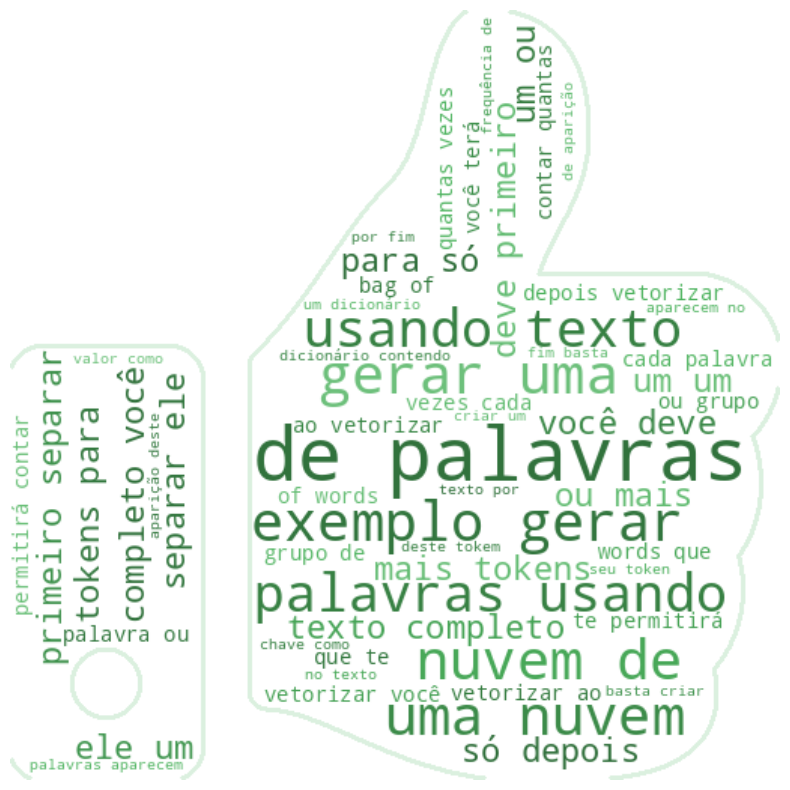

(<wordcloud.wordcloud.WordCloud at 0x784fdddbef20>, 56)

In [ ]:
# Exemplo com uma frase completa
texto = """Exemplo: Gerar uma nuvem de palavras usando texto completo você deve
           primeiro separar ele um um ou mais tokens, para só depois vetorizar.
           Ao vetorizar você terá a bag of words, que te permitirá contar
           quantas vezes cada palavra ou grupo de palavras aparecem no texto.
           Por fim, basta criar um dicionário contendo a chave como o seu token
           e o valor como a frequência de aparição deste tokem."""
# Vetorização e contagem de frequência simples de bigramas:
vectorizer = CountVectorizer(ngram_range=(2, 2))
bag_of_words = vectorizer.fit_transform([a+' '+b for a,b in (ngrams(texto.split(),2))])
sum_words = bag_of_words.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
words_dict = dict(words_freq)
print(words_dict)

gerar_nuvem_palavras(dicionario_tokens_e_frequencia=words_dict,
                      arquivo_mascara='thumbs_up_mask.png')